In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
defaults = pd.read_csv("../data/defaults_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
customers = pd.read_csv("../data/customers_cleaned.csv")

In [3]:
defaults['Default_Date'] = pd.to_datetime(
    defaults['Default_Date'],
    errors='coerce'
)

In [4]:
defaults['Default_Date'].dtype

dtype('<M8[us]')

In [5]:
monthly_defaults = defaults.groupby(
    defaults['Default_Date'].dt.to_period('M')
).size()

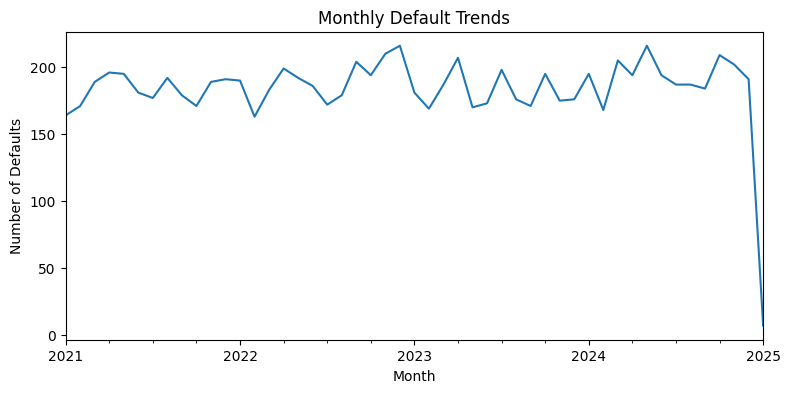

In [6]:
monthly_defaults.plot(kind='line', figsize=(9,4))
plt.title("Monthly Default Trends")
plt.xlabel("Month")
plt.ylabel("Number of Defaults")
plt.show()

In [7]:
default_loan = defaults.merge(
    loans[['Loan_ID', 'Loan_Amount']],
    on='Loan_ID',
    how='left'
)

avg_default_amt = default_loan.groupby(
    pd.cut(default_loan['Loan_Amount'], bins=3)
)['Default_Amount'].mean()

avg_default_amt

Loan_Amount
(45491.192, 1699708.333]      53618.031683
(1699708.333, 3348977.667]    52710.970385
(3348977.667, 4998247.0]      52595.183214
Name: Default_Amount, dtype: float64

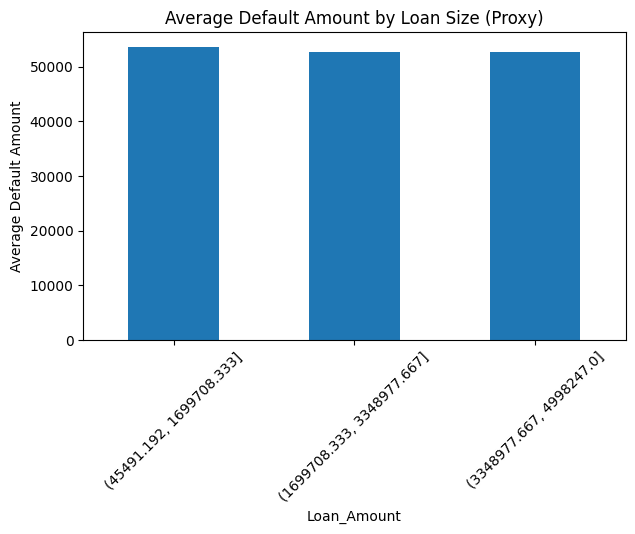

In [8]:
avg_default_amt.plot(kind='bar', figsize=(7,4))
plt.title("Average Default Amount by Loan Size (Proxy)")
plt.ylabel("Average Default Amount")
plt.xticks(rotation=45)
plt.show()

In [9]:
customers['Income_Band'] = pd.qcut(
    customers['Annual_Income'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

In [10]:
loan_customer_default = loans.merge(
    customers[['Customer_ID', 'Income_Band']],
    on='Customer_ID',
    how='left'
).merge(
    defaults[['Loan_ID']],
    on='Loan_ID',
    how='left',
    indicator=True
)

loan_customer_default['Default_Flag'] = (
    loan_customer_default['_merge'] == 'both'
).astype(int)

In [11]:
income_default_rate = loan_customer_default.groupby(
    'Income_Band'
)['Default_Flag'].mean()

income_default_rate

Income_Band
Low Income       0.100162
Middle Income    0.101710
High Income      0.096593
Name: Default_Flag, dtype: float64

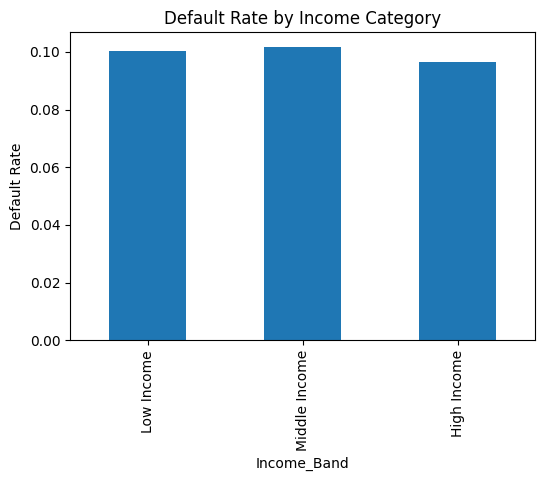

In [12]:
income_default_rate.plot(kind='bar', figsize=(6,4))
plt.title("Default Rate by Income Category")
plt.ylabel("Default Rate")
plt.show()

### Task 14 – Default Trend Insights

- Defaults exhibit time-based fluctuations, indicating cyclical risk patterns
- Higher loan size segments show larger average default amounts
- Lower income customer segments experience higher default rates
- Income-based risk profiling can improve credit decision-making